In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
data = pd.read_csv('data/gaiadr3_color_mag.csv').dropna()

data['Abs_mag'] = data['phot_g_mean_mag'] - 5*np.log10(data['distance_gspphot'])+5
print(f"Before cuts: {data.shape[0]:,}")

# Cuts as described in eq. (11) of Lindergen et al. 
# (https://arxiv.org/abs/1804.09366) to go here.
...
print(f"After cuts: {data.shape[0]:,}")


# Color and mag cuts not to be included in cut count. Only matters for plotting purposes
color_cuts=(1.8, 3.5)
mag_cuts=(8,12)
data = data.where(
    (data['bp_rp']>color_cuts[0]) & (data['bp_rp']<color_cuts[1]) &
    (data['Abs_mag']>mag_cuts[0]) & (data['Abs_mag']<mag_cuts[1])
).dropna()

Before cuts: 118,077
After cuts: 118,077


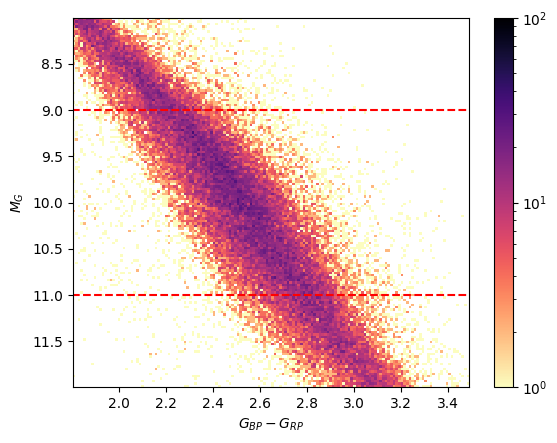

In [ ]:
from matplotlib.colors import LogNorm
from matplotlib import colormaps 
fig, ax = plt.subplots()

cmap = colormaps['magma'].reversed()

h = ax.hist2d(data['bp_rp'], data['Abs_mag'], bins=150, cmap=cmap, norm=LogNorm(vmin=1e0, vmax=1e2))#, vmin=0, vmax=10)
ax.plot([color_cuts[0], color_cuts[1]], [9,9], 'r--')
ax.plot([color_cuts[0], color_cuts[1]], [11,11], 'r--')
ax.invert_yaxis()

ax.set(
    xlabel=r'$G_{BP} - G_{RP}$',
    ylabel=r'$M_G$'
)

fig.colorbar(h[3], ax=ax)
plt.show()